In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from typing import List, Literal
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix

In [2]:
df = pd.read_csv('data.csv')
df.head()

,review,target
0,sản_phẩm đẹp hình,1
1,giao hàng rất nhanh cần gấp nấu mở thất_vọng v...,0
2,chảo vênh lòng cao giữa trũng xung_quanh rán k...,0
3,hàng tốt,1
4,bình tốt giá_cả hợp_lý màu tím thiên màu tím t...,1


In [3]:
df['target'].value_counts().to_frame()

,count
target,
1,49719
0,10960


<Axes: xlabel='target', ylabel='count'>

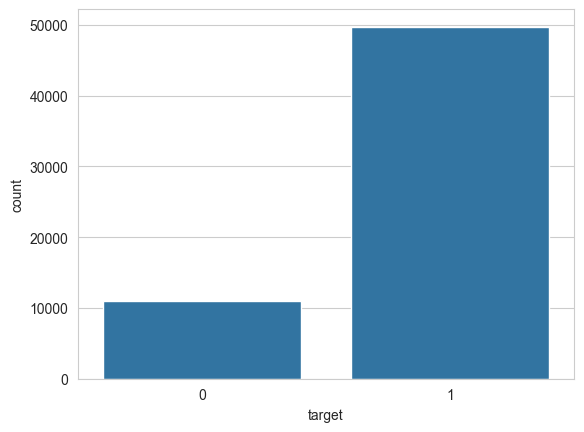

In [4]:
sns.countplot(data=df, x='target')

In [5]:
x_full, y_full = df['review'], df['target']
SEED = 42

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x_full, y_full, test_size=0.2, stratify=y_full, random_state=SEED)

In [7]:
x_train.shape

(48543,)

In [8]:
x_test.shape

(12136,)

In [9]:
y_train.shape

(48543,)

In [10]:
y_test

2189     1
56624    1
25220    1
7214     1
3658     1
        ..
6003     1
4793     1
18177    1
49838    1
47996    1
Name: target, Length: 12136, dtype: int64

In [11]:
bow_vectorizer = CountVectorizer()
x_train_bow = bow_vectorizer.fit_transform(x_train)
x_test_bow = bow_vectorizer.transform(x_test)

tfidf_vectorizer = TfidfVectorizer()
x_train_tfidf = tfidf_vectorizer.fit_transform(x_train)
x_test_tfidf = tfidf_vectorizer.transform(x_test)

In [12]:
def train_and_test_knn(x_train, y_train, x_test, y_test, n_neighbors:int = 5):
    knn = KNeighborsClassifier()
    knn.fit(x_train, y_train)

    y_pred = knn.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)

    report = classification_report(y_test, y_pred, output_dict=True)

    return y_pred, accuracy, report

In [13]:
knn_bow_labels, knn_bow_accuracy, knn_bow_report = train_and_test_knn(x_train_bow, y_train, x_test_bow, y_test)
knn_tfidf_labels, knn_tfidf_accuracy, knn_tfidf_report = train_and_test_knn(x_train_tfidf, y_train, x_test_tfidf,
                                                                            y_test)

print("Accuracy for knn:")
print(f"Bag of Words: {knn_bow_accuracy:.4f}")
print(f"TF-IDF: {knn_tfidf_accuracy:.4f}")

Accuracy for knn:
Bag of Words: 0.8509
TF-IDF: 0.8280
